In [2]:
import pandas as pd       # для роботи з таблицями (DataFrame)
import numpy as np  
import matplotlib.pyplot as plt   # графіки
import seaborn as sns 
from sklearn.model_selection import train_test_split   # розбиття на train/test
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler      # нормалізація / масштабування фіч
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [3]:
pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv('../data/tml/2020.csv')

In [5]:
df.describe()

,draw_size,tourney_date,match_num,winner_seed,winner_ht,winner_age,winner_rank,winner_rank_points,loser_seed,loser_ht,loser_age,loser_rank,loser_rank_points,best_of,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced
count,1466.000000,1.466000e+03,1466.000000,554.000000,1458.000000,1466.000000,1451.000000,1451.000000,310.000000,1432.000000,1465.000000,1428.000000,1428.000000,1466.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.00000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000
mean,55.950887,2.020056e+07,29.635061,7.687726,187.527435,26.970073,76.528601,1933.309442,8.719355,186.551676,27.293466,107.452381,1188.339636,3.519782,119.630670,7.258459,2.695464,82.434125,52.082793,39.286537,16.558675,13.151188,3.819294,5.50252,5.357811,3.335493,85.771778,52.746580,35.068395,15.135349,12.894888,5.138949,9.155508
std,44.278705,3.893614e+02,30.600205,7.322212,7.167733,4.700289,132.750369,2339.330673,7.723495,7.055841,4.632156,174.655825,1373.621500,0.877448,45.006416,5.758480,2.298067,31.059778,20.585372,14.477846,6.751799,4.515922,3.157905,4.25072,5.141875,2.557925,31.520825,21.293015,15.649679,7.044453,4.532039,3.442632,4.415261
min,4.000000,2.020010e+07,1.000000,1.000000,170.000000,15.855000,1.000000,1.000000,1.000000,170.000000,16.208000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,2.020020e+07,8.000000,3.000000,183.000000,22.919000,18.000000,689.500000,4.000000,183.000000,23.379000,33.750000,544.500000,3.000000,85.000000,3.000000,1.000000,59.000000,36.000000,28.000000,12.000000,10.000000,1.000000,2.00000,2.000000,2.000000,63.000000,38.000000,24.000000,10.000000,10.000000,3.000000,6.000000
50%,32.000000,2.020031e+07,19.000000,5.000000,188.000000,26.992000,44.000000,1124.000000,6.000000,185.000000,27.296000,67.000000,835.000000,3.000000,114.000000,6.000000,2.000000,78.000000,49.000000,37.000000,16.000000,12.000000,3.000000,5.00000,4.000000,3.000000,81.000000,49.000000,33.000000,14.000000,12.000000,4.000000,9.000000
75%,128.000000,2.020093e+07,38.000000,9.000000,193.000000,30.402250,87.000000,2052.500000,10.000000,191.000000,30.470000,108.000000,1343.500000,5.000000,142.000000,10.000000,4.000000,99.000000,63.000000,47.000000,20.000000,15.000000,6.000000,8.00000,7.000000,4.000000,102.000000,64.000000,43.000000,19.000000,15.000000,7.000000,11.000000
max,128.000000,2.020112e+07,127.000000,32.000000,211.000000,40.893000,1671.000000,11830.000000,32.000000,211.000000,41.506000,1752.000000,11830.000000,5.000000,365.000000,46.000000,16.000000,244.000000,161.000000,102.000000,44.000000,36.000000,19.000000,30.00000,52.000000,15.000000,215.000000,154.000000,104.000000,43.000000,36.000000,27.000000,35.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1466 entries, 0 to 1465
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          1466 non-null   object 
 1   tourney_name        1466 non-null   object 
 2   surface             1466 non-null   object 
 3   draw_size           1466 non-null   int64  
 4   tourney_level       1466 non-null   object 
 5   indoor              1353 non-null   object 
 6   tourney_date        1466 non-null   int64  
 7   match_num           1466 non-null   int64  
 8   winner_id           1466 non-null   object 
 9   winner_seed         554 non-null    float64
 10  winner_entry        231 non-null    object 
 11  winner_name         1466 non-null   object 
 12  winner_hand         1463 non-null   object 
 13  winner_ht           1458 non-null   float64
 14  winner_ioc          1466 non-null   object 
 15  winner_age          1466 non-null   float64
 16  winner

In [7]:
df.columns

Index(['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'indoor', 'tourney_date', 'match_num', 'winner_id', 'winner_seed',
       'winner_entry', 'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc',
       'winner_age', 'winner_rank', 'winner_rank_points', 'loser_id',
       'loser_seed', 'loser_entry', 'loser_name', 'loser_hand', 'loser_ht',
       'loser_ioc', 'loser_age', 'loser_rank', 'loser_rank_points', 'score',
       'best_of', 'round', 'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn',
       'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace',
       'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms',
       'l_bpSaved', 'l_bpFaced'],
      dtype='object')

In [8]:
df_check = df.copy()

missing_types = {
    'NaN (pandas NA)': df_check.isna().sum(),
    'Empty strings': (df_check == '').sum(),
    'Whitespace only': df_check.apply(lambda x: x.astype(str).str.strip() == '').sum() if df_check.select_dtypes(include='object').shape[1] > 0 else pd.Series(),
}

for col in df_check.columns:  # ВСІ текстові колонки
    unique_vals = df_check[col].unique()
    potential_missing = [v for v in unique_vals if pd.isna(v) or str(v).strip().lower() in ['', 'na', 'nan', 'null', 'none', 'n/a', '-', '?']]
    if potential_missing:
        print(f"  {col}: {potential_missing}")

  indoor: [nan]
  winner_seed: [np.float64(nan)]
  winner_entry: [nan]
  winner_hand: [nan]
  winner_ht: [np.float64(nan)]
  winner_rank: [np.float64(nan)]
  winner_rank_points: [np.float64(nan)]
  loser_seed: [np.float64(nan)]
  loser_entry: [nan]
  loser_hand: [nan]
  loser_ht: [np.float64(nan)]
  loser_age: [np.float64(nan)]
  loser_rank: [np.float64(nan)]
  loser_rank_points: [np.float64(nan)]
  minutes: [np.float64(nan)]
  w_ace: [np.float64(nan)]
  w_df: [np.float64(nan)]
  w_svpt: [np.float64(nan)]
  w_1stIn: [np.float64(nan)]
  w_1stWon: [np.float64(nan)]
  w_2ndWon: [np.float64(nan)]
  w_SvGms: [np.float64(nan)]
  w_bpSaved: [np.float64(nan)]
  w_bpFaced: [np.float64(nan)]
  l_ace: [np.float64(nan)]
  l_df: [np.float64(nan)]
  l_svpt: [np.float64(nan)]
  l_1stIn: [np.float64(nan)]
  l_1stWon: [np.float64(nan)]
  l_2ndWon: [np.float64(nan)]
  l_SvGms: [np.float64(nan)]
  l_bpSaved: [np.float64(nan)]
  l_bpFaced: [np.float64(nan)]


In [9]:
missing_stats = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isna().sum(),
    'Missing_Percent': (df.isna().sum() / len(df) * 100).round(2),
    'Non_Missing': len(df) - df.isna().sum(),
    'Total_Rows': len(df)
})

missing_stats = missing_stats.sort_values('Missing_Count', ascending=False)

missing_stats_filtered = missing_stats[missing_stats['Missing_Count'] > 0]

print(missing_stats_filtered.to_string(index=False))

            Column  Missing_Count  Missing_Percent  Non_Missing  Total_Rows
      winner_entry           1235            84.24          231        1466
        loser_seed           1156            78.85          310        1466
       loser_entry           1151            78.51          315        1466
       winner_seed            912            62.21          554        1466
            indoor            113             7.71         1353        1466
         l_bpFaced             77             5.25         1389        1466
         w_bpFaced             77             5.25         1389        1466
              w_df             77             5.25         1389        1466
            w_svpt             77             5.25         1389        1466
           w_1stIn             77             5.25         1389        1466
          w_1stWon             77             5.25         1389        1466
          w_2ndWon             77             5.25         1389        1466
           w

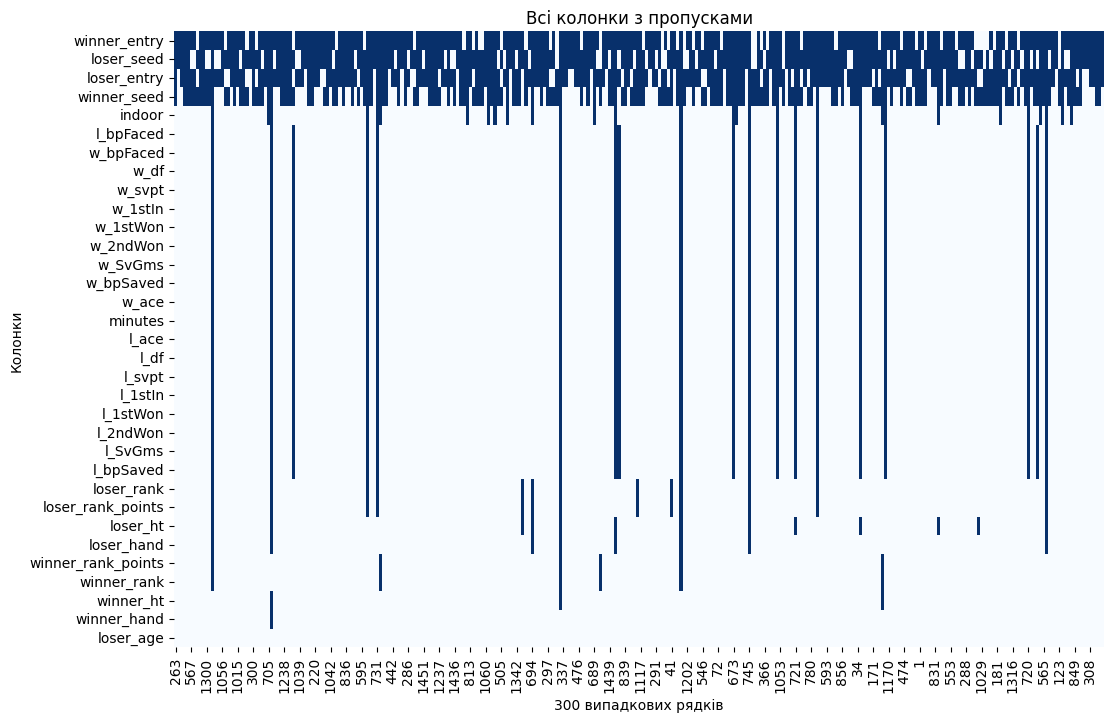

In [20]:
cols_with_missing = missing_stats_filtered['Column'].tolist() 

plt.figure(figsize=(12, 8))
sns.heatmap(df[cols_with_missing].sample(300).isna().T,
            cmap = 'Blues',
            cbar=False,
            yticklabels=cols_with_missing)  

plt.title('Всі колонки з пропусками')
plt.xlabel('300 випадкових рядків')
plt.ylabel('Колонки')
plt.show()

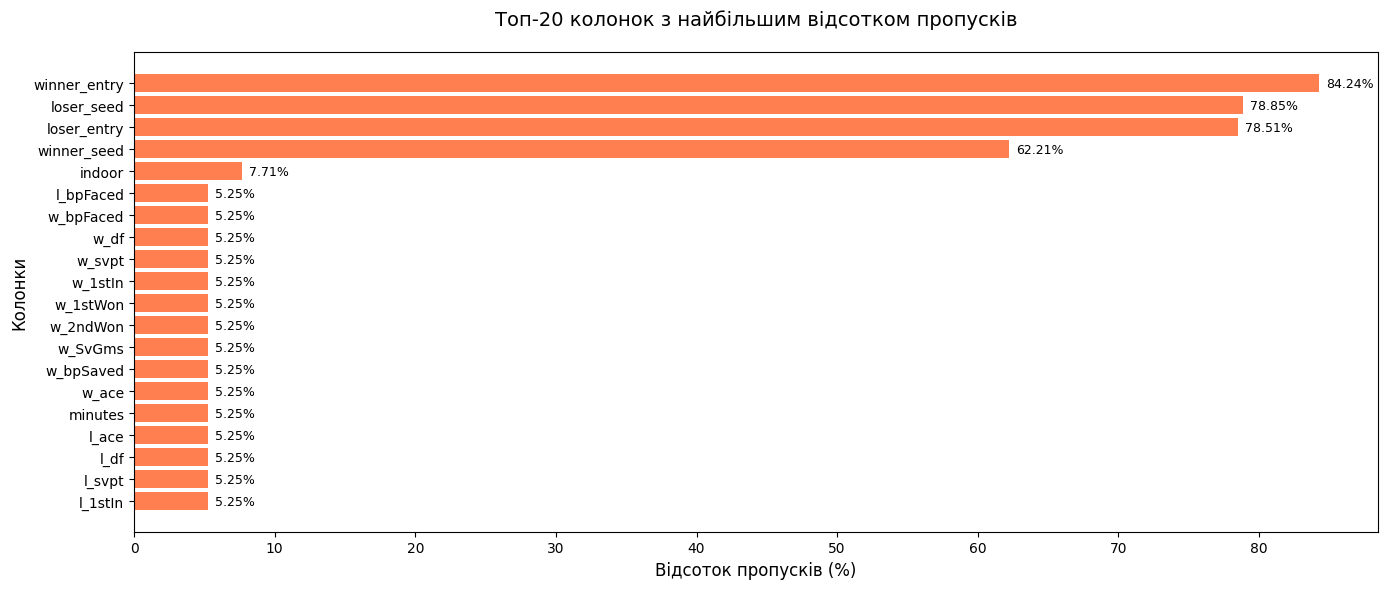

In [21]:
if len(missing_stats_filtered) > 0:
    plt.figure(figsize=(14, 6))
    
    top_20_missing = missing_stats_filtered.head(20)
    
    plt.barh(range(len(top_20_missing)), top_20_missing['Missing_Percent'], color='coral')
    plt.yticks(range(len(top_20_missing)), top_20_missing['Column'].to_list())
    plt.xlabel('Відсоток пропусків (%)', fontsize=12)
    plt.ylabel('Колонки', fontsize=12)
    plt.title('Топ-20 колонок з найбільшим відсотком пропусків', fontsize=14, pad=20)
    plt.gca().invert_yaxis()
    
    # Додаємо значення на барах
    for i, v in enumerate(top_20_missing['Missing_Percent']):
        plt.text(v + 0.5, i, f'{v}%', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

In [24]:
print("\n=== Повна таблиця статистики пропусків ===\n")
print(missing_stats.to_string(index=False))


=== Повна таблиця статистики пропусків ===

            Column  Missing_Count  Missing_Percent  Non_Missing  Total_Rows
      winner_entry           1235            84.24          231        1466
        loser_seed           1156            78.85          310        1466
       loser_entry           1151            78.51          315        1466
       winner_seed            912            62.21          554        1466
            indoor            113             7.71         1353        1466
         l_bpFaced             77             5.25         1389        1466
         w_bpFaced             77             5.25         1389        1466
              w_df             77             5.25         1389        1466
            w_svpt             77             5.25         1389        1466
           w_1stIn             77             5.25         1389        1466
          w_1stWon             77             5.25         1389        1466
          w_2ndWon             77          